# CoCiP Implementation for Comparison to APCEMM

In [199]:
# Import functions from the pipeline_fxn_lib.py script
import sys
sys.path.append('/home/chinahg/GCresearch/contrailuncertainty/start_here/')
import pipeline_fxn_lib as lib

import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

from pycontrails import Flight
from pycontrails.datalib.ecmwf import ERA5
from pycontrails.models.cocip import Cocip
from pycontrails.models.humidity_scaling import ConstantHumidityScaling
from pycontrails.physics import units
from pycontrails import MetDataset

# Set the aircraft and flight parameters to match LES simulations

## Make CSV if needed

In [256]:
make_csv = True  # Set to True to create the CSV file
test_id = "110T225L25"  # Example test ID

if make_csv == True:
    # Update the CSV file with B767 characteristics
    df_flight = pd.read_csv("flight-cocip.csv")

    df_flight["Altitude (m)"] = 10700 # Set altitude to 10.7 km
    df_flight["True airspeed (m s-1)"] = 237  # Set true airspeed to 237 m/s

    # Calculate the mach number
    gamma = 1.4  # Specific heat ratio for air at 10.7 km
    T = int(test_id[4:7])  # Temperature at 10.7 km in Kelvin, e.g., "205" from "110T205L25"
    R = 286.9  # Specific gas constant for dry air in J/(kg·K)
    a = np.sqrt(gamma*R*T)  # Speed of sound at 10.7 km
    M = df_flight["True airspeed (m s-1)"] / a  # Speed of sound at 10.7 km
    df_flight["Mach Number"] = M  # Set Mach number

    df_flight["Aircraft mass (kg)"] = 152281.72  # At beginning of cruise (35k ft) for B767-300 (uses Trent 4000, same as all B767 models)
    df_flight["Fuel mass flow rate (kg s-1)"] = 1.36986 # Estimated using cruise velocity and fuel flow rate from Lewellen et al. (2014)
    df_flight["Overall propulsion efficiency"] = 0.3  # Set overall propulsion efficiency to 30%
    df_flight["nvPM number emissions index (kg-1)"] = 9.11**15 # Number per kg fuel
    df_flight["ICAO Aircraft Type"] = "B767"
    df_flight["Wingspan (m)"] = 47.25 # Set wingspan to 47.25 m

    # Calculate the UTC time in seconds for 2023-01-01 00:00:00 at 60 second intervals
    df_flight["UTC time"] = pd.date_range(start="2023-01-01 00:00:00", periods=len(df_flight), freq="60s").astype(np.int64) // 10**9
    df_flight["time"] = pd.to_datetime(df_flight["UTC time"], origin="unix", unit="s") # Convert the UTC time to datetimes and assign to the "time" column

    # Save the updated DataFrame to a new CSV file
    df_flight.to_csv("110T205L25-flight-cocip.csv", index=False, mode="w")

## Load and format the flight data CSV

In [257]:
df_flight = pd.read_csv("110T205L25-flight-cocip.csv")

# constant properties along the length of the flight
attrs = {
    "flight_id": "fid",
    "aircraft_type": df_flight["ICAO Aircraft Type"].values[0],
    "wingspan": df_flight["Wingspan (m)"].values[0]
}

# rename a few columns for compatibility with `Flight` requirements
df_flight = df_flight.rename(
    columns={
        "Longitude (degrees)": "longitude",
        "Latitude (degrees)": "latitude",
        "True airspeed (m s-1)": "true_airspeed",
        "Mach Number": "mach_number",
        "Aircraft mass (kg)": "aircraft_mass",
        "Fuel mass flow rate (kg s-1)": "fuel_flow",
        "Overall propulsion efficiency": "engine_efficiency",
        "nvPM number emissions index (kg-1)": "nvpm_ei_n",
        "Altitude (m)": "altitude",
    }
)

# clean up a few columns before building Flight class
df_flight = df_flight.drop(
    columns=["ICAO Aircraft Type", "Wingspan (m)", "UTC time"]
)

fl = Flight(data=df_flight, attrs=attrs)
fl

Flight [11 keys x 162 length, 3 attributes]
	Keys: longitude, latitude, Altitude (feet), true_airspeed, mach_number, ..., time
	Attributes:
	time                [2023-01-01 00:00:00, 2023-01-01 02:41:00]
	longitude           [-50.0, -10.07]
	latitude            [55.185, 61.089]
	altitude            [10700.0, 10700.0]
	flight_id           fid
	aircraft_type       B767
	wingspan            47.25

# Download radiation data from ERA5

In [258]:
# get met and rad domain from Flight
time = (
    pd.to_datetime(fl["time"][0]).floor("h"),
    pd.to_datetime(fl["time"][-1]).ceil("h") + pd.Timedelta("80h"),
)
# Download radiation data from ERA5
era5sl = ERA5(time=time, variables=Cocip.rad_variables)

# Create new meteorology to match LES simulations

In [259]:
# create `MetDataset` from sources
rad = era5sl.open_metdataset()

In [260]:
met_from_scratch = False  # Set to True to create the met dataset from scratch

if met_from_scratch:
    # Make the met file

    # Import APCEMM met data
    xr_apcemm_met = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/{test_id}/{test_id}.nc")

    # Define dimensions
    longitudes = np.linspace(-180, 179.75, int((180+179.75)/(0.25) + 1))

    latitudes = np.linspace(30, 70, int((70-30)/(0.25) + 1))
    levels = np.flip(xr_apcemm_met['pressure'].values)

    UTC = pd.date_range(start="2023-01-01 00:00:00", periods=60, freq="1h").astype(np.int64) // 10**9
    time = pd.to_datetime(UTC, origin="unix", unit="s") # Convert the UTC time to datetimes and assign to the "time" column

    # Define the additional coordinates to add
    altitudes = np.flip((xr_apcemm_met['altitude'].values).astype(np.float32)) * 1000  # Convert altitude from km to m
    pressures = levels * 100  # Convert pressure from hPa to Pa

    # Define the shpae of the dataset
    new_shape = (len(longitudes), len(latitudes), len(levels), len(time))

    # Create the data to be saved in the new dataset (variables)
    air_temperature = np.broadcast_to(
        np.flip(xr_apcemm_met['temperature'][:,0].values)[np.newaxis, np.newaxis, :, np.newaxis],
        new_shape
    ).astype(np.float32)

    relative_humidity = np.broadcast_to(
        np.flip(xr_apcemm_met['relative_humidity_ice'][:,0].values)[np.newaxis, np.newaxis, :, np.newaxis],
        new_shape
    ).astype(np.float32)

    northward_wind = np.zeros_like(relative_humidity, dtype=np.float32) # Stays 0, only horizontal shearing
    lagrangian_tendency_of_air_pressure = np.zeros_like(relative_humidity, dtype=np.float32) # Stays 0, no downward motion
    specific_cloud_ice_water_content = np.zeros_like(relative_humidity, dtype=np.float32) # Stays 0, no cloud cover

    # Calculate the specific humidity based on RHi and temperature
    T0 = 273.15  # Reference temperature in Kelvin
    T_base = air_temperature[0,0,:,0] # Temperature in Kelvin
    RHi_base = relative_humidity[0,0,:,0]
    pres_base = levels * 100  # Pressure in Pa
    P_sat_w = lib.compute_Psat_w(T_base)
    P_sat_i = lib.compute_Psat_i(T_base)
    q_base = (RHi_base * P_sat_i / P_sat_w) * (1 / (0.263 * pres_base)) * np.exp((17.67 * (T_base - T0)) / (T_base - 29.65))
    specific_humidity = np.broadcast_to(
            q_base[np.newaxis, np.newaxis, :, np.newaxis],  # lon, lat, level, time
            new_shape
        ).astype(np.float32)

    # Calculate the wind feild for constant shear of 0.004 m/s/m
    slope = 0.004  # m/s/m
    u = slope * levels
    eastward_wind = np.broadcast_to(
            u[np.newaxis, np.newaxis, :, np.newaxis],  # lon, lat, level, time
            new_shape
        ).astype(np.float32)

    # Create dataset with the variables and coordinates defined above
    ds_met = xr.Dataset(
        {
            "air_temperature": (['longitude', 'latitude', 'level', 'time'], air_temperature),
            "specific_humidity": (['longitude', 'latitude', 'level', 'time'], specific_humidity),
            "eastward_wind": (['longitude', 'latitude', 'level', 'time'], eastward_wind),
            "northward_wind": (['longitude', 'latitude', 'level', 'time'], northward_wind),
            "lagrangian_tendency_of_air_pressure": (['longitude', 'latitude', 'level', 'time'], lagrangian_tendency_of_air_pressure),
            "specific_cloud_ice_water_content": (['longitude', 'latitude', 'level', 'time'], specific_cloud_ice_water_content),
            "relative_humidity": (['longitude', 'latitude', 'level', 'time'], relative_humidity),

        },
        coords={
            'longitude': longitudes,
            'latitude': latitudes,
            'level': levels,
            'time': time,
            'altitude': ('level', altitudes),
            'air_pressure': ('level', pressures)
        },
        attrs=None
    )

    # Save the modified xr_met to a new NetCDF file
    ds_met.to_netcdf(f"{test_id}-met.nc", mode="w", format="NETCDF4")

else:
    # Load in the existing met file
    ds_met = xr.open_dataset(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/CoCiP/{test_id}-met.nc", )

In [261]:
ds_met

<xarray.Dataset> Size: 49GB
Dimensions:                              (longitude: 1440, latitude: 161,
                                          level: 125, time: 60)
Coordinates:
  * longitude                            (longitude) float64 12kB -180.0 ... ...
  * latitude                             (latitude) float64 1kB 30.0 ... 70.0
  * level                                (level) float64 1kB 181.5 ... 1.013e+03
  * time                                 (time) datetime64[ns] 480B 2023-01-0...
    altitude                             (level) float32 500B ...
    air_pressure                         (level) float64 1kB ...
Data variables:
    air_temperature                      (longitude, latitude, level, time) float32 7GB ...
    specific_humidity                    (longitude, latitude, level, time) float32 7GB ...
    eastward_wind                        (longitude, latitude, level, time) float32 7GB ...
    northward_wind                       (longitude, latitude, level, time) float32 7GB ...
    lagrangian_tendency_of_air_pressure  (longitude, latitude, level, time) float32 7GB ...
    specific_cloud_ice_water_content     (longitude, latitude, level, time) float32 7GB ...
    relative_humidity                    (longitude, latitude, level, time) float32 7GB ...

In [262]:
# ds_met["air_temperature"] = ds_met["air_temperature"] - 0.5
# # Save the modified xr_met to a new NetCDF file
# ds_met.to_netcdf(f"{test_id}-met.nc", mode="w", format="NETCDF4")

## Plot the meteorological input variables

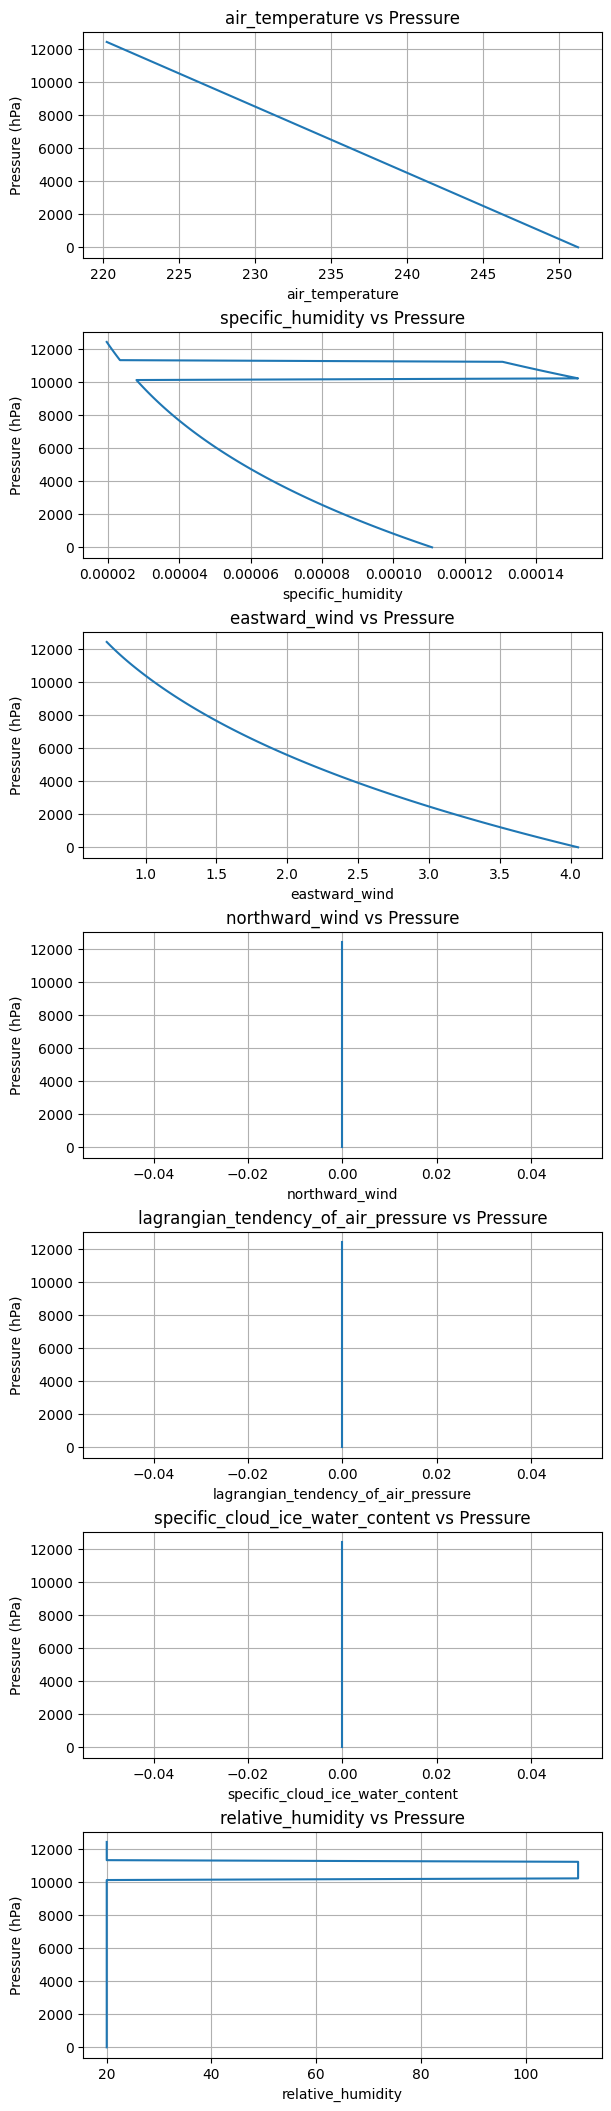

In [263]:
# Plot each variable in ds_met as a function of altitude for the first lat, lon, and time indices

fig, axs = plt.subplots(len(ds_met.data_vars), 1, figsize=(6, 3 * len(ds_met.data_vars)), constrained_layout=True)

for i, var in enumerate(ds_met.data_vars):
    # Select the first longitude, latitude, and time index for each variable
    data = ds_met[var].isel(longitude=0, latitude=0, time=0)
    axs[i].plot(data.values, ds_met['altitude'].values)
    axs[i].set_xlabel(var)
    axs[i].set_ylabel('Pressure (hPa)')
    axs[i].set_title(f"{var} vs Pressure")
    axs[i].grid(True)

plt.show()

## Reformat the met input to work with CoCiP

In [264]:
# Rename the dimensions to match the expected format
new_met = MetDataset(ds_met)

# Run CoCiP

In [265]:
params = {
    "process_emissions": False,
    "verbose_outputs": True,
    "humidity_scaling": ConstantHumidityScaling(rhi_adj=0.98),
    "max_age": np.timedelta64(60, "h"),
    "min_n_ice_per_m3": 1e-5 * 461862376.35,
    
}
cocip = Cocip(met=new_met, rad=rad, params=params)

In [266]:
fl_out = cocip.eval(source=fl)

In [267]:
fl_out.dataframe.columns

Index(['waypoint', 'longitude', 'latitude', 'Altitude (feet)', 'true_airspeed',
       'mach_number', 'aircraft_mass', 'fuel_flow', 'engine_efficiency',
       'nvpm_ei_n', 'altitude', 'time', 'flight_id', 'level', 'air_pressure',
       'air_temperature', 'specific_humidity', 'u_wind', 'v_wind', 'rhi',
       'tau_cirrus', 'specific_cloud_ice_water_content', 'rho_air', 'sdr',
       'segment_length', 'sin_a', 'cos_a', 'G', 'T_sat_liquid', 'rh',
       'rh_critical_sac', 'sac', 'T_critical_sac', 'width', 'depth', 'rhi_1',
       'air_temperature_1', 'specific_humidity_1', 'altitude_1',
       'persistent_1', 'dT_dz', 'ds_dz', 'dz_max', 'rho_air_1', 'iwc_1',
       'f_surv', 'n_ice_per_m_0', 'n_ice_per_m_1', 'ef', 'contrail_age',
       'sdr_mean', 'sdr_min', 'sdr_max', 'rsr_mean', 'rsr_min', 'rsr_max',
       'olr_mean', 'olr_min', 'olr_max', 'rf_sw_mean', 'rf_sw_min',
       'rf_sw_max', 'rf_lw_mean', 'rf_lw_min', 'rf_lw_max', 'rf_net_mean',
       'rf_net_min', 'rf_net_max', 'cocip']

In [268]:
fl_out.dataframe

,waypoint,longitude,latitude,Altitude (feet),true_airspeed,mach_number,aircraft_mass,fuel_flow,engine_efficiency,nvpm_ei_n,...,rf_sw_mean,rf_sw_min,rf_sw_max,rf_lw_mean,rf_lw_min,rf_lw_max,rf_net_mean,rf_net_min,rf_net_max,cocip
0,0,-10.070,55.185,36000,237,0.788366,152281.72,1.36986,0.3,2.470448e+14,...,0.0,0.0,0.0,18.308025,13.138352,21.618294,18.308025,13.138352,21.618294,1.0
1,1,-10.273,55.222,36000,237,0.788366,152281.72,1.36986,0.3,2.470448e+14,...,0.0,0.0,0.0,19.105505,13.750432,22.342087,19.105504,13.750432,22.342087,1.0
2,2,-10.476,55.258,36000,237,0.788366,152281.72,1.36986,0.3,2.470448e+14,...,0.0,0.0,0.0,19.596107,14.039211,22.820557,19.596107,14.039211,22.820557,1.0
3,3,-10.680,55.295,36000,237,0.788366,152281.72,1.36986,0.3,2.470448e+14,...,0.0,0.0,0.0,19.853767,14.297001,22.858885,19.853767,14.297001,22.858885,1.0
4,4,-10.883,55.331,36000,237,0.788366,152281.72,1.36986,0.3,2.470448e+14,...,0.0,0.0,0.0,20.073727,14.479789,22.986120,20.073728,14.479789,22.986120,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,157,-49.002,61.027,36000,237,0.788366,152281.72,1.36986,0.3,2.470448e+14,...,0.0,0.0,0.0,10.654538,5.787418,13.635347,10.654538,5.787418,13.635347,1.0
158,158,-49.274,61.019,36000,237,0.788366,152281.72,1.36986,0.3,2.470448e+14,...,0.0,0.0,0.0,12.040805,8.240910,16.242990,12.040805,8.240910,16.242990,1.0
159,159,-49.546,61.010,36000,237,0.788366,152281.72,1.36986,0.3,2.470448e+14,...,0.0,0.0,0.0,12.418791,8.887717,16.791344,12.418791,8.887717,16.791344,1.0
160,160,-49.818,61.000,36000,237,0.788366,152281.72,1.36986,0.3,2.470448e+14,...,0.0,0.0,0.0,12.524801,8.658550,17.059372,12.524801,8.658550,17.059372,1.0


In [269]:
cocip.contrail

,waypoint,flight_id,formation_time,time,age,longitude,latitude,altitude,level,continuous,...,dn_dt_agg,dn_dt_turb,rf_sw,rf_lw,rf_net,persistent,ef,timestep,age_hours,dt_integration
index,,,,,,,,,,,,,,,,,,,,,
0,0,fid,2023-01-01 00:00:00,2023-01-01 00:30:00,0 days 00:30:00,-10.042899,55.185,10650.221884,239.081825,True,...,8.912929e-17,0.000008,0.0,13.138352,13.138352,True,2.207702e+10,0,0.500000,0 days 00:30:00
1,1,fid,2023-01-01 00:01:00,2023-01-01 00:30:00,0 days 00:29:00,-10.246778,55.222,10650.323652,239.078028,True,...,8.861172e-17,0.000008,0.0,13.750432,13.750432,True,2.194159e+10,0,0.483333,0 days 00:29:00
2,2,fid,2023-01-01 00:02:00,2023-01-01 00:30:00,0 days 00:28:00,-10.450659,55.258,10650.425421,239.074231,True,...,8.809133e-17,0.000008,0.0,14.039211,14.039211,True,2.149694e+10,0,0.466667,0 days 00:28:00
3,3,fid,2023-01-01 00:03:00,2023-01-01 00:30:00,0 days 00:27:00,-10.655541,55.295,10650.527192,239.070434,True,...,8.756991e-17,0.000009,0.0,14.297001,14.297001,True,2.062316e+10,0,0.450000,0 days 00:27:00
4,4,fid,2023-01-01 00:04:00,2023-01-01 00:30:00,0 days 00:26:00,-10.859426,55.331,10650.628964,239.066637,True,...,8.704347e-17,0.000009,0.0,14.479789,14.479789,True,1.979447e+10,0,0.433333,0 days 00:26:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1612,157,fid,2023-01-01 02:37:00,2023-01-01 07:30:00,0 days 04:53:00,-48.685334,61.027,10137.881692,258.825942,True,...,3.781527e-16,0.000005,0.0,5.787418,5.787418,True,3.120968e+11,14,4.883333,0 days 00:30:00
1613,158,fid,2023-01-01 02:38:00,2023-01-01 07:30:00,0 days 04:52:00,-48.958537,61.019,10144.298932,258.570733,True,...,5.204383e-16,0.000005,0.0,8.240910,8.240910,True,3.979058e+11,14,4.866667,0 days 00:30:00
1614,159,fid,2023-01-01 02:39:00,2023-01-01 07:30:00,0 days 04:51:00,-49.231750,61.010,10150.687522,258.316865,True,...,6.708842e-16,0.000005,0.0,9.765410,9.765410,True,4.299356e+11,14,4.850000,0 days 00:30:00


In [270]:
waypoint_2 = cocip.contrail[cocip.contrail.waypoint == 2]

In [271]:
waypoint_2.keys()

Index(['waypoint', 'flight_id', 'formation_time', 'time', 'age', 'longitude',
       'latitude', 'altitude', 'level', 'continuous', 'segment_length',
       'sin_a', 'cos_a', 'width', 'depth', 'sigma_yz', 'air_temperature',
       'specific_humidity', 'air_pressure', 'rhi', 'rho_air', 'q_sat',
       'n_ice_per_m', 'iwc', 'u_wind', 'v_wind', 'vertical_velocity',
       'tau_cirrus', 'air_temperature_lower', 'u_wind_lower', 'v_wind_lower',
       'dT_dz', 'ds_dz', 'dsn_dz', 'sdr', 'top_net_solar_radiation', 'rsr',
       'top_net_thermal_radiation', 'olr', 'area_eff', 'plume_mass_per_m',
       'r_ice_vol', 'terminal_fall_speed', 'diffuse_h', 'diffuse_v',
       'n_ice_per_vol', 'tau_contrail', 'dn_dt_agg', 'dn_dt_turb', 'rf_sw',
       'rf_lw', 'rf_net', 'persistent', 'ef', 'timestep', 'age_hours',
       'dt_integration'],
      dtype='object')

In [272]:
waypoint_2

,waypoint,flight_id,formation_time,time,age,longitude,latitude,altitude,level,continuous,...,dn_dt_agg,dn_dt_turb,rf_sw,rf_lw,rf_net,persistent,ef,timestep,age_hours,dt_integration
index,,,,,,,,,,,,,,,,,,,,,
2,2,fid,2023-01-01 00:02:00,2023-01-01 00:30:00,0 days 00:28:00,-10.450659,55.258,10650.425421,239.074231,True,...,8.809133e-17,0.000008,0.0,14.039211,14.039211,True,2.149694e+10,0,0.466667,0 days 00:28:00
32,2,fid,2023-01-01 00:02:00,2023-01-01 01:00:00,0 days 00:58:00,-10.423496,55.258,10644.305328,239.302650,True,...,1.305801e-16,0.000007,0.0,18.257011,18.257011,True,6.218734e+10,1,0.966667,0 days 00:30:00
92,2,fid,2023-01-01 00:02:00,2023-01-01 01:30:00,0 days 01:28:00,-10.396307,55.258,10632.811027,239.732127,True,...,1.773780e-16,0.000006,0.0,19.011524,19.011524,True,1.110246e+11,2,1.466667,0 days 00:30:00
182,2,fid,2023-01-01 00:02:00,2023-01-01 02:00:00,0 days 01:58:00,-10.369069,55.258,10615.013255,240.398360,True,...,2.405359e-16,0.000006,0.0,19.907204,19.907204,True,1.626913e+11,3,1.966667,0 days 00:30:00
302,2,fid,2023-01-01 00:02:00,2023-01-01 02:30:00,0 days 02:28:00,-10.341755,55.258,10588.813229,241.381846,True,...,3.303340e-16,0.000005,0.0,18.693516,18.693516,True,2.112278e+11,4,2.466667,0 days 00:30:00
452,2,fid,2023-01-01 00:02:00,2023-01-01 03:00:00,0 days 02:58:00,-10.314330,55.258,10550.874837,242.811734,True,...,4.640093e-16,0.000006,0.0,20.242437,20.242437,True,2.740321e+11,5,2.966667,0 days 00:30:00
614,2,fid,2023-01-01 00:02:00,2023-01-01 03:30:00,0 days 03:28:00,-10.286742,55.258,10495.814849,244.899125,True,...,6.714924e-16,0.000006,0.0,22.663416,22.663416,True,3.788688e+11,6,3.466667,0 days 00:30:00
776,2,fid,2023-01-01 00:02:00,2023-01-01 04:00:00,0 days 03:58:00,-10.258917,55.258,10414.733306,247.999457,True,...,1.009450e-15,0.000007,0.0,22.820557,22.820557,True,4.967203e+11,7,3.966667,0 days 00:30:00
938,2,fid,2023-01-01 00:02:00,2023-01-01 04:30:00,0 days 04:28:00,-10.230740,55.258,10292.302439,252.741032,True,...,1.586554e-15,0.000007,0.0,20.730091,20.730091,True,5.892437e+11,8,4.466667,0 days 00:30:00


In [273]:
# Convert the waypoint_2 DataFrame to a DataSet
waypoint_2_ds = waypoint_2.to_xarray()

In [274]:
# Save the waypoint_2 DataFrame to a .nc file
waypoint_2_ds.to_netcdf(f"{test_id}-bypass.nc")

# Plot key variables for a single waypoint

First reported contrail age:  0.4666666666666667


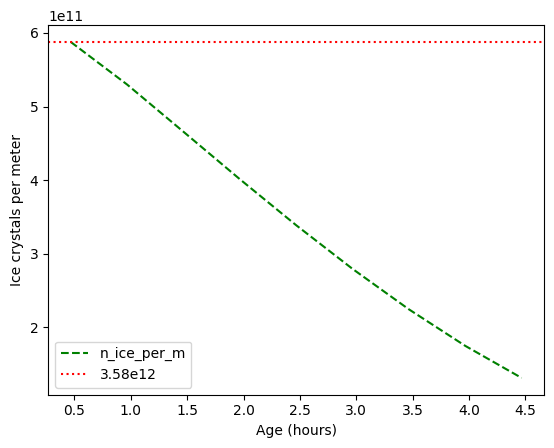

In [284]:
ax = plt.axes()
waypoint_2.plot(
    "age_hours",
    "n_ice_per_m",
    ax=ax,
    xlabel="Age (hours)",
    ylabel="Ice crystals per meter",
    color="green",
    legend=False,
    linestyle='--',
)
ax.axhline(5.88e11, color='red', linestyle=':', label='3.58e12')
ax.legend()
print("First reported contrail age: ", waypoint_2.age_hours.values[0])

np.float64(44552975.325939685)

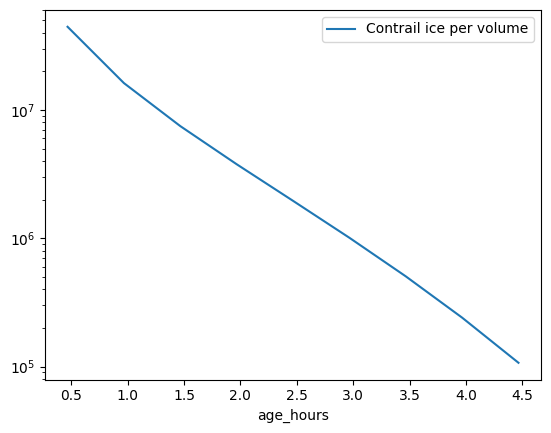

In [276]:
ax = plt.axes()
waypoint_2.plot(
    "age_hours",
    "n_ice_per_vol",
    ax=ax,
    label="Contrail ice per volume"
)
ax.set_yscale("log")

waypoint_2["n_ice_per_vol"].iloc[0]

<Axes: xlabel='age_hours'>

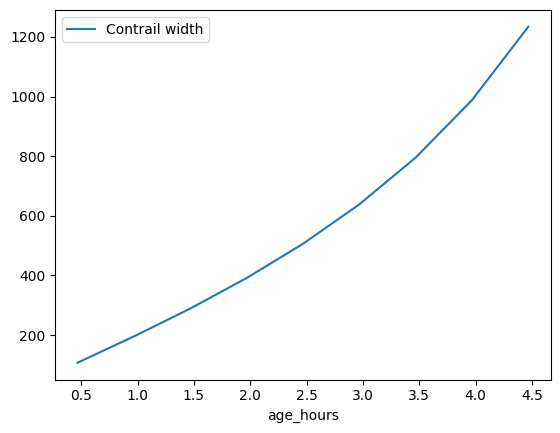

In [277]:
ax = plt.axes()
waypoint_2.plot(
    "age_hours",
    "width",

    ax=ax,
    label="Contrail width"
)

<Axes: xlabel='age_hours'>

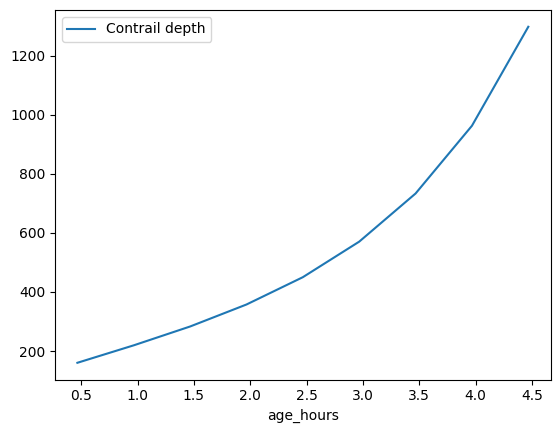

In [278]:
ax = plt.axes()
waypoint_2.plot(
    "age_hours",
    "depth",

    ax=ax,
    label="Contrail depth"
)

<Axes: xlabel='Age (hours)', ylabel='Contrail Altitude [m]'>

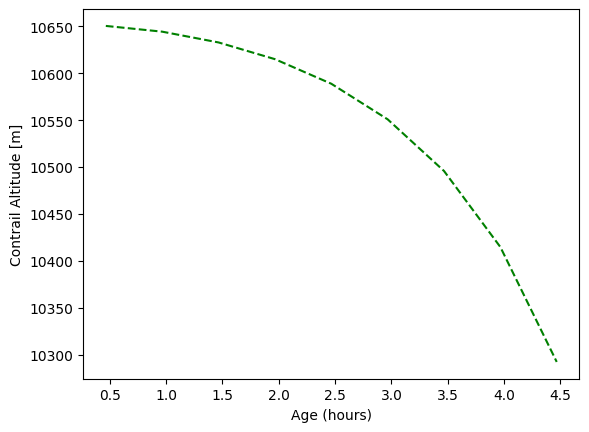

In [279]:
ax = plt.axes()
waypoint_2.plot(
    "age_hours",
    "altitude",

    ax=ax,

    xlabel="Age (hours)",
    ylabel="Contrail Altitude [m]",
    color="green",
    linestyle='--',
    legend=False
)

<Axes: xlabel='age_hours'>

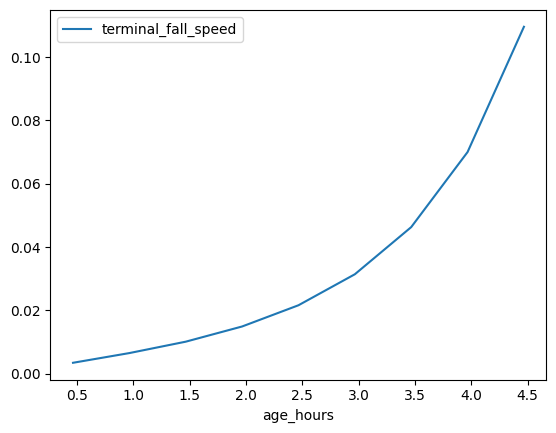

In [280]:
ax = plt.axes()
waypoint_2.plot(
    "age_hours",
    "terminal_fall_speed",

    ax=ax,
    label="terminal_fall_speed"
)

<Axes: xlabel='age_hours'>

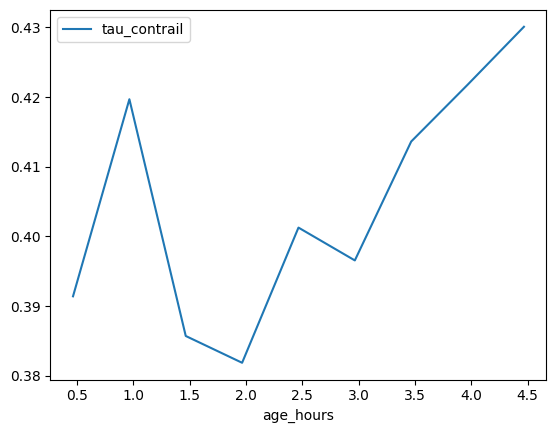

In [281]:
ax = plt.axes()
waypoint_2.plot(
    "age_hours",
    "tau_contrail",

    ax=ax,
    label="tau_contrail"
)

<Axes: xlabel='Age (hours)', ylabel='Ice crystal radius (microns)'>

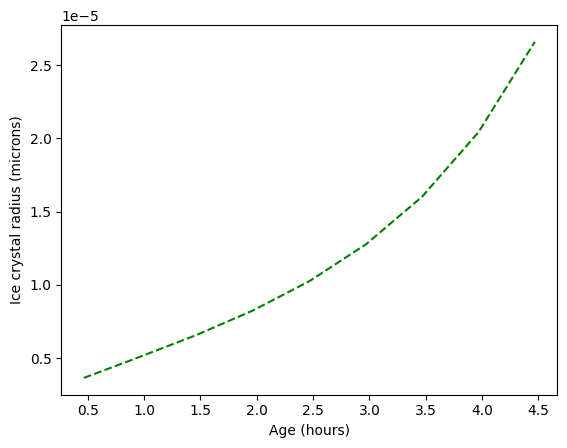

In [282]:
ax = plt.axes()
waypoint_2.plot(
    "age_hours",
    "r_ice_vol",

    ax=ax,

    xlabel="Age (hours)",
    ylabel="Ice crystal radius (microns)",
    color="green",
    legend=False,
    linestyle='--',
)

In [283]:
ds_met.close()

# Extra/Old Code